---  BUDGET SUMMARY ---
Total Income:   ₹35,000.00
Total Expenses: ₹20,962.51
Monthly Savings:₹14,037.49 (40.1% Savings Rate)

---  AI EXPENSE PREDICTION ---
Average Daily Spend: ₹676.21/day
Projected 30-Day Spend: ₹20,286.30
Status: On Track 

 Final report exported successfully to 'categorized_budget_report.csv'



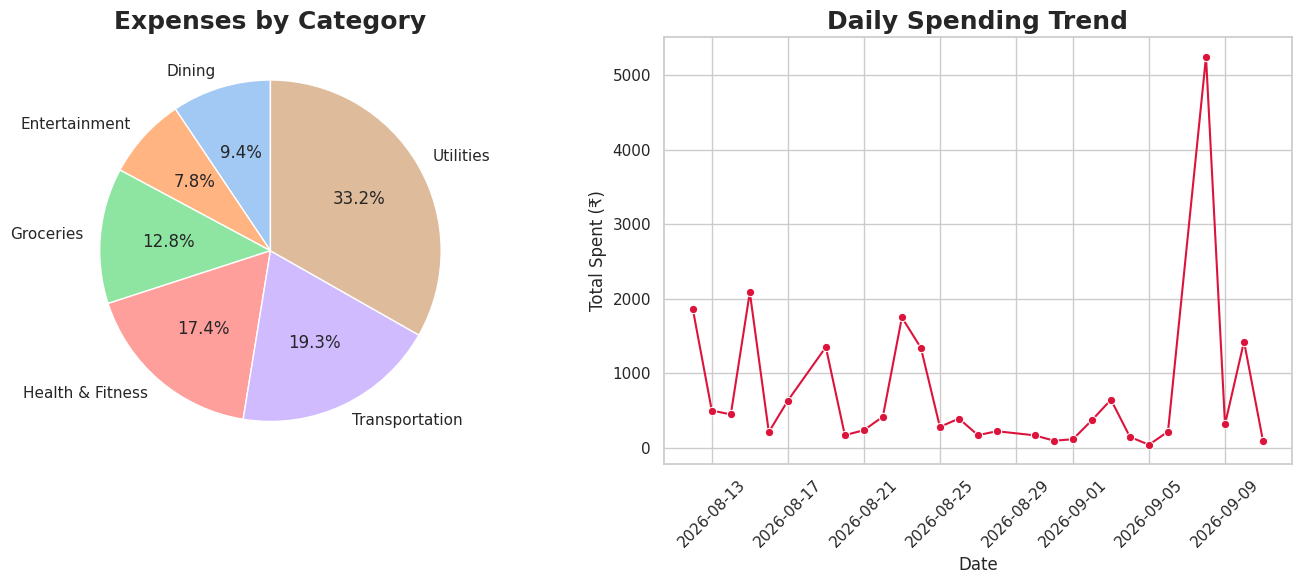

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Import Monthly Expense Data ---
df = pd.read_csv('monthly_expenses.csv')
df['Date'] = pd.to_datetime(df['Date'])

# --- 2. Categorize Expenses Automatically ---
def categorize(desc):
    desc = str(desc).lower()
    if any(w in desc for w in ['uber', 'petrol', 'rapido', 'transit']): return 'Transportation'
    if any(w in desc for w in ['netflix', 'spotify', 'movie']): return 'Entertainment'
    if any(w in desc for w in ['whole foods', 'target', 'vishal megamart', 'groceries']): return 'Groceries'
    if any(w in desc for w in ['rent', 'electric', 'internet', 'bill', 'water']): return 'Utilities'
    if any(w in desc for w in ['restaurant', 'starbucks', 'cafe', 'food']): return 'Dining'
    if 'gym' in desc: return 'Health & Fitness'
    return 'Miscellaneous'

df['Category'] = df['Description'].apply(categorize)

# --- 3. Calculate Monthly Savings & 4. Generate Budget Summary ---
monthly_income = 35000.00  # You can adjust this value
total_expenses = df['Amount'].sum()
savings = monthly_income - total_expenses
savings_rate = (savings / monthly_income) * 100 if monthly_income > 0 else 0

print("---  BUDGET SUMMARY ---")
print(f"Total Income:   ₹{monthly_income:,.2f}")
print(f"Total Expenses: ₹{total_expenses:,.2f}")
print(f"Monthly Savings:₹{savings:,.2f} ({savings_rate:.1f}% Savings Rate)\n")

# --- BONUS: Expense Prediction ---
days_in_data = (df['Date'].max() - df['Date'].min()).days + 1
if days_in_data > 0:
    avg_daily_spend = total_expenses / days_in_data
    projected_monthly_spend = avg_daily_spend * 30
    
    trend_status = "Over Budget " if projected_monthly_spend > monthly_income else "On Track "
    
    print("---  AI EXPENSE PREDICTION ---")
    print(f"Average Daily Spend: ₹{avg_daily_spend:.2f}/day")
    print(f"Projected 30-Day Spend: ₹{projected_monthly_spend:,.2f}")
    print(f"Status: {trend_status}\n")

# --- 6. Export Final Report ---
output_filename = 'categorized_budget_report.csv'
df.to_csv(output_filename, index=False)
print(f" Final report exported successfully to '{output_filename}'\n")

# --- 5. Visualize Spending Trends ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart A: Expenses by Category
category_totals = df.groupby('Category')['Amount'].sum()
axes[0].pie(category_totals, labels=category_totals.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
axes[0].set_title('Expenses by Category',fontweight ='bold', fontsize = 18)

# Chart B: Daily Spending Trend
daily_spending = df.groupby('Date')['Amount'].sum().reset_index()
sns.lineplot(data=daily_spending, x='Date', y='Amount', ax=axes[1], marker='o', color='crimson')
axes[1].set_title('Daily Spending Trend',fontweight ='bold', fontsize = 18)
axes[1].set_ylabel('Total Spent (₹)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()